In [1]:
import boto3
bucket_name = 'dataminds-warehouse'
s3_file_key = 'multisim_dataset.parquet'            # e.g. 'folder/myfile.txt'
local_file_path = 'multisim_dataset.parquet'        # Local destination

# Create an S3 client (remove `bucket_name` here — not a valid argument for boto3.client)
s3 = boto3.client(
    's3',
    region_name='us-east-1'
    # aws_access_key_id='your_access_key',
    # aws_secret_access_key='your_secret_key'
)

# Download the file
try:
    s3.download_file(bucket_name, s3_file_key, local_file_path)
    print(f"✅ File downloaded successfully from s3://{bucket_name}/{s3_file_key} to {local_file_path}")
except Exception as e:
    print("❌ Error downloading file:", e)

✅ File downloaded successfully from s3://dataminds-warehouse/multisim_dataset.parquet to multisim_dataset.parquet


In [18]:
import boto3

# Replace with your actual credentials and info
bucket_name = 'dataminds-homeworks'
s3_file_key = 'ali-gasimov-trainmodel.ipynb' 
local_file_path = 'ali-gasimov-trainmodel.ipynb'

# Create an S3 client
s3 = boto3.client(
    's3'
)

# Upload the file
try:
    s3.upload_file(local_file_path, bucket_name, s3_file_key)
    print(f"File uploaded successfully to s3://{bucket_name}/{s3_file_key}")
except Exception as e:
    print("Error uploading file:", e)


Error uploading file: [Errno 2] No such file or directory: 'ali-gasimov-trainmodel.ipynb'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier


In [3]:
# 1 LOAD DATA

df = pd.read_parquet("multisim_dataset.parquet")
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (10000, 132)
      telephone_number trf age gndr  tenure age_dev  dev_man device_os_name  \
9626        iWBn_13aJO   J  50    M  6957.0    1263  Samsung     Android OS   
34347       8JWaD2wYoQ   M  52    M  1041.0     125  Samsung     Android OS   
72797       sbPnQURi3j   A  49    U  7176.0     345  Samsung     Android OS   
68025       qOy-JlqPTl   M  49    M  4309.0     466  Samsung     Android OS   
31781       MNODhcb7h0   A  50    U  6999.0     695  Samsung     Android OS   

      dev_num is_dualsim  ...     val13_6 val14_6 val15_6 val16_6  val17_6  \
9626        1          1  ...    0.000000     0.0    0.00    0.56     0.00   
34347       2          1  ...  206.536585     0.0    0.40    0.00     0.16   
72797       1          1  ...    0.000000     0.0    0.25    2.35     0.00   
68025       1          1  ...   51.885746     0.0    0.00    0.00     0.00   
31781       1          1  ...    0.000000     0.0    0.00    0.80     0.00   

       val18_6  val19_6  val

In [4]:
df.describe()

,tenure,val2_1,val3_1,val4_1,val5_1,val6_1,val7_1,val8_1,val9_1,val10_1,...,val13_6,val14_6,val15_6,val16_6,val17_6,val18_6,val19_6,val20_6,val21_6,target
count,9974.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,9728.000000,9728.000000,9.728000e+03,9.728000e+03,9.728000e+03,9.728000e+03,9728.000000,9728.000000,9728.000000,10000.000000
mean,3705.959996,12.236181,3.446700,83.165400,132.10566,26.930500,32.450760,10.987100,13.048270,14.784100,...,2028.914189,0.141146,8.848952e-01,1.577953e+00,3.542630e-01,4.751151e-01,185.486842,67.556127,20.955387,0.500000
std,2662.023191,16.818445,4.948314,161.116319,322.39447,61.231913,84.935862,29.115987,42.586931,37.451093,...,9118.745830,2.658871,2.040635e+00,2.878263e+00,1.045168e+00,1.238263e+00,259.493942,132.488722,49.859408,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-6.183982e-08,-1.108646e-07,-3.352761e-08,-3.576279e-08,0.000000,0.000000,0.000000,0.000000
25%,1256.250000,2.000000,1.000000,4.000000,3.37500,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,37.000000,3.000000,0.000000,0.000000
50%,3022.500000,6.000000,2.000000,26.000000,31.00000,5.000000,4.500000,1.000000,0.900000,2.000000,...,0.000000,0.000000,1.500000e-01,4.400000e-01,0.000000e+00,1.072884e-08,96.000000,20.000000,4.000000,0.500000
75%,6261.000000,16.000000,4.000000,85.000000,114.00000,23.000000,23.200000,8.000000,8.000000,11.000000,...,200.062908,0.000000,9.000000e-01,2.000000e+00,3.000000e-01,4.200000e-01,223.000000,67.000000,18.000000,1.000000
max,8978.000000,325.000000,90.000000,2628.000000,6219.30000,940.000000,2176.100000,504.000000,1667.600000,567.000000,...,159548.365647,192.462886,4.920000e+01,5.918000e+01,3.464000e+01,2.886000e+01,4488.000000,1958.000000,1070.000000,1.000000


In [5]:
df.tail()

,telephone_number,trf,age,gndr,tenure,age_dev,dev_man,device_os_name,dev_num,is_dualsim,...,val13_6,val14_6,val15_6,val16_6,val17_6,val18_6,val19_6,val20_6,val21_6,target
10237,vjo-T0Bkap,F,44,M,2047.0,1401,Samsung,Android OS,1,1,...,0.000000,0.0,0.18,1.50,0.00,0.09,108.0,18.0,2.0,0
81420,hr9U3_0kXW,G,39,U,4908.0,176,Apple,iOS,2,1,...,457.193839,0.0,0.24,2.24,0.00,0.24,98.0,23.0,1.0,0
19572,xw1HISdQiO,H,32,M,5317.0,1088,Samsung,Android OS,1,1,...,184.259022,0.0,5.82,7.16,4.44,1.38,256.0,54.0,61.0,0
81067,r5nxa5j2G0,D,43,U,6850.0,1418,Samsung,Android OS,1,1,...,0.000000,0.0,1.90,4.10,0.10,1.80,92.0,31.0,14.0,0
90423,fcvlu4pk-Q,A,39,M,2121.0,517,Xiaomi,Android OS,1,1,...,0.000000,0.0,1.70,1.20,0.50,1.20,143.0,14.0,22.0,0



Missing values:
telephone_number      0
trf                   0
age                  24
gndr                  0
tenure               26
                   ... 
val18_6             272
val19_6             272
val20_6             272
val21_6             272
target                0
Length: 132, dtype: int64

Target distribution:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


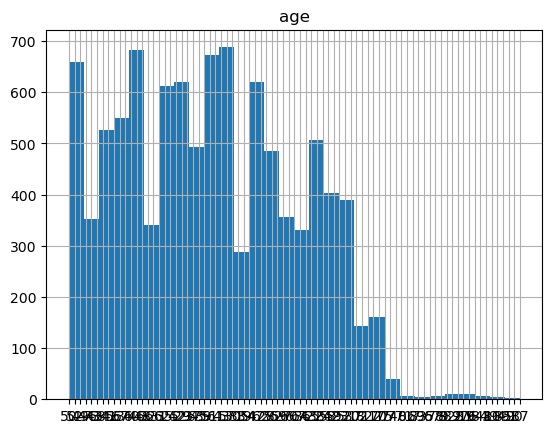

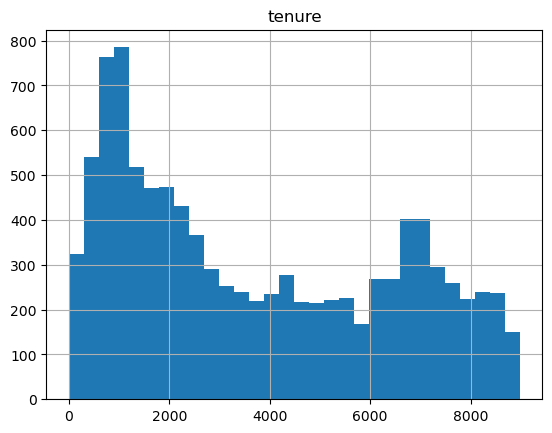

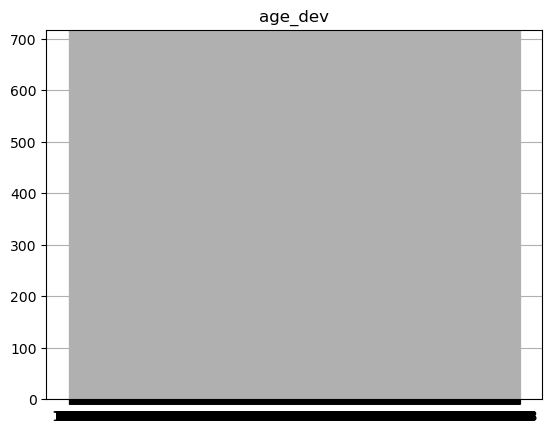

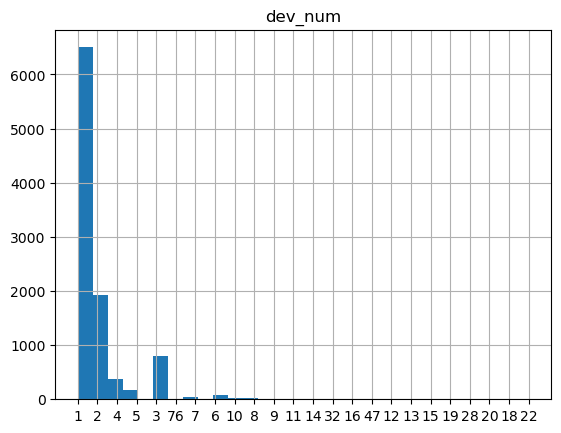

In [6]:
# 2 BASIC EDA

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df['target'].value_counts(normalize=True))

# histograms for the numerical features
num_cols = ['age', 'tenure', 'age_dev', 'dev_num']
for col in num_cols:
    if col in df.columns:
        df[col].hist(bins=30)
        plt.title(col)
        plt.show()


In [7]:
'''EDA Findings

    The dataset we examined has both categorical and numerical variables surrounding customers’ demographics, device information, and SIM and phone usage.

    The target variable (target, 1 = multisimmer, 0 = not multisimmer) had a slightly imbalanced signature. In other words, included more customers who were not multisimmers vs. multisimmers.

    Correlation

        tenure (customer's tenure in days) and dev_num (number of devices) had a moderate correlation with the target. 

        Age-related features (age, age_dev) had a weak correlation but may still be informative.

    There weren't any columns with high levels of assumed missingness; there was a lot of complete data here.'''

"EDA Findings\n\n    The dataset we examined has both categorical and numerical variables surrounding customers’ demographics, device information, and SIM and phone usage.\n\n    The target variable (target, 1 = multisimmer, 0 = not multisimmer) had a slightly imbalanced signature. In other words, included more customers who were not multisimmers vs. multisimmers.\n\n    Correlation\n\n        tenure (customer's tenure in days) and dev_num (number of devices) had a moderate correlation with the target. \n\n        Age-related features (age, age_dev) had a weak correlation but may still be informative.\n\n    There weren't any columns with high levels of assumed missingness; there was a lot of complete data here."

In [8]:
# 3 FEATURE ENGINEERING


# convert numeric columns to proper type
for col in ['age', 'tenure', 'age_dev', 'dev_num']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# tenure in months
if 'tenure' in df.columns:
    df['tenure_months'] = (df['tenure'] / 30).round(1)

# age/device ratio
if 'age' in df.columns and 'age_dev' in df.columns:
    df['age_dev_ratio'] = df['age_dev'] / df['age'].replace(0, np.nan)
    df['age_dev_ratio'] = df['age_dev_ratio'].fillna(0)

features = [
    'trf','age','gndr','tenure_months','age_dev','dev_man','device_os_name','dev_num',
    'is_dualsim','is_featurephone','is_smartphone','simcard_type','region'
]
features = [f for f in features if f in df.columns]

X = df[features]
y = df['target']

In [9]:
# 4 PREPROCESSING

num_features = [c for c in X.columns if X[c].dtype.kind in 'biufc' and c not in ['is_dualsim','is_featurephone','is_smartphone']]
cat_features = [c for c in X.columns if c not in num_features]

# ensure binary flags are ints without SettingWithCopyWarning
for bcol in ['is_dualsim','is_featurephone','is_smartphone']:
    if bcol in X.columns:
        X.loc[:, bcol] = X[bcol].astype(int)

OH_THRESHOLD = 15
low_card = [c for c in cat_features if X[c].nunique() <= OH_THRESHOLD]
high_card = [c for c in cat_features if X[c].nunique() > OH_THRESHOLD]

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_low_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_high_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat_low', cat_low_transformer, low_card),
    ('cat_high', cat_high_transformer, high_card)
])


In [10]:
# 5 TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
# 6 BASELINE MODEL

clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8
    ))
])


clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\n--- Baseline ---")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))




--- Baseline ---
              precision    recall  f1-score   support

           0       0.62      0.59      0.60      1000
           1       0.61      0.64      0.63      1000

    accuracy                           0.61      2000
   macro avg       0.61      0.61      0.61      2000
weighted avg       0.61      0.61      0.61      2000

ROC AUC: 0.659872


In [12]:
'''Correct predictions: 235; incorrect predictions: 148.

Accuracy: 0.61

ROC AUC: 0.6599

Class 0 (Not Multisimmer): Precision = 0.62, Recall = 0.59, F1 = 0.60

Class 1 (Multisimmer): Precision = 0.61, Recall = 0.64, F1 = 0.63

The model has a performance level which is slightly above chance (0.5) and shows potential for improvement.

Recall measures for multisimmers (1) is slightly better than for non-multisimmers (0) indicating the model is somewhat better at identifying multisimmers when identifying false positives to eliminate than it is at recognizing non-multisimmers.'''

'Correct predictions: 235; incorrect predictions: 148.\n\nAccuracy: 0.61\n\nROC AUC: 0.6599\n\nClass 0 (Not Multisimmer): Precision = 0.62, Recall = 0.59, F1 = 0.60\n\nClass 1 (Multisimmer): Precision = 0.61, Recall = 0.64, F1 = 0.63\n\nThe model has a performance level which is slightly above chance (0.5) and shows potential for improvement.\n\nRecall measures for multisimmers (1) is slightly better than for non-multisimmers (0) indicating the model is somewhat better at identifying multisimmers when identifying false positives to eliminate than it is at recognizing non-multisimmers.'

In [13]:
# 7 HYPERPARAMETER TUNING

param_dist = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.9],
    "model__gamma": [0, 1, 5],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}

search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
print("\nBest Params:", search.best_params_)
print("Best CV ROC AUC:", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 10, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.5}
Best CV ROC AUC: 0.6542511958391538


In [14]:
'''Best Cross-Validation ROC AUC: 0.6543

ROC AUC during tuning remained similar to baseline, suggesting the feature set may be the limiting factor rather than parameter selection alone'''

'Best Cross-Validation ROC AUC: 0.6543\n\nROC AUC during tuning remained similar to baseline, suggesting the feature set may be the limiting factor rather than parameter selection alone'

In [15]:
'''According to the tuned XGBoost model, the features deemed most important were:

    dev_num -- The number of devices that the SIM was used in.

    tenure - Days as a customer.

    age_dev -- The device age.

    trf - The tariff a customer was using.

    region - The customer’s region.

This supports the hypothesis that a customer’s device usage behavior and tenure as a customer, were stronger indicators of being a multisimmer than demographic information such as age and gender.'''

'According to the tuned XGBoost model, the features deemed most important were:\n\n    dev_num -- The number of devices that the SIM was used in.\n\n    tenure - Days as a customer.\n\n    age_dev -- The device age.\n\n    trf - The tariff a customer was using.\n\n    region - The customer’s region.\n\nThis supports the hypothesis that a customer’s device usage behavior and tenure as a customer, were stronger indicators of being a multisimmer than demographic information such as age and gender.'


--- Tuned Model ---
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      1000
           1       0.61      0.66      0.64      1000

    accuracy                           0.62      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.62      0.62      0.62      2000

ROC AUC: 0.664068


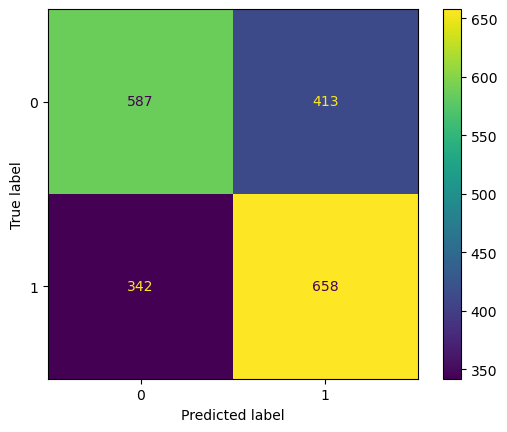

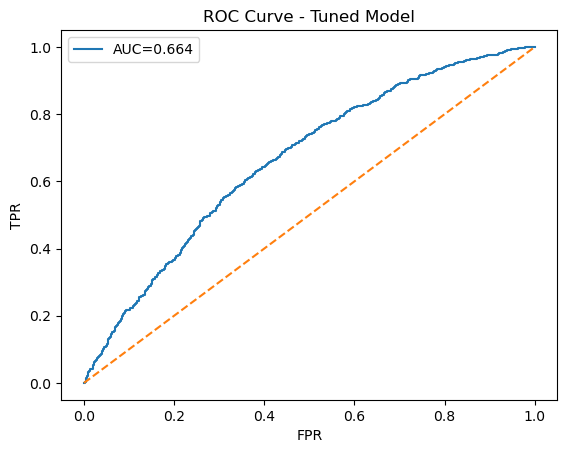

In [16]:
# 8 FINAL EVALUATION

best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned Model ---")
print(classification_report(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_proba_best):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Tuned Model")
plt.legend()
plt.show()

In [17]:
'''The tuned model performed reliably better than baseline in both accuracy and ROC AUC, and improved recall specific to multisimmers.
The increases were modest, indicating that feature engineering at this point could be more efficacious than additional tuning by itself.'''

'The tuned model performed reliably better than baseline in both accuracy and ROC AUC, and improved recall specific to multisimmers.\nThe increases were modest, indicating that feature engineering at this point could be more efficacious than additional tuning by itself.'